<a href="https://colab.research.google.com/github/JAHANTRISHA/Research-with-Python/blob/main/Introduction_to_Machine_Learning/Assignment_6_Introduction_to_Machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Question 1: Find the Best Tree Depth
###Task: Test depths 3, 4, 5 and find highest accuracy

### Import All Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score, auc
)
import matplotlib.pyplot as plt
import seaborn as sns

### Mount Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Load Dataset

In [3]:
print("Firstly, we have to load the cancer dataset.")

import warnings
warnings.filterwarnings('ignore')
data = pd.read_csv('/content/drive/MyDrive/skillMorph/Class6/Breast_Cancer_Wisconsin_Dataset.csv')

print(f"Dataset loaded! We have data from {len(data)} real patients")
print(f"Each patient has {len(data.columns)-2} medical measurements")

# Show first few patients
print("\nFirst 5 patients in our dataset:")
print(data[['id', 'diagnosis', 'radius_mean', 'texture_mean', 'area_mean']].head())

# Understand diagnosis column
print(f"\nUnderstanding Diagnosis:")
diagnosis_counts = data['diagnosis'].value_counts()
print(f"M (Malignant = Dangerous Cancer):  {diagnosis_counts['M']} patients")
print(f"B (Benign = Harmless Cancer):      {diagnosis_counts['B']} patients")
print(f"Total patients:                    {len(data)} patients")

Firstly, we have to load the cancer dataset.
Dataset loaded! We have data from 569 real patients
Each patient has 31 medical measurements

First 5 patients in our dataset:
         id diagnosis  radius_mean  texture_mean  area_mean
0    842302         M        17.99         10.38     1001.0
1    842517         M        20.57         17.77     1326.0
2  84300903         M        19.69         21.25     1203.0
3  84348301         M        11.42         20.38      386.1
4  84358402         M        20.29         14.34     1297.0

Understanding Diagnosis:
M (Malignant = Dangerous Cancer):  212 patients
B (Benign = Harmless Cancer):      357 patients
Total patients:                    569 patients


### Prepare Dataset with 5 Features

In [4]:
print("Computers only understand numbers, not letters!")
print("Converting M → 1 (Malignant Cancer) and B → 0 (Benign Cancer)")

# Convert diagnosis to numbers
data['diagnosis_numeric'] = data['diagnosis'].map({'M': 1, 'B': 0})
print("Conversion completed!")

# Select only the most important features (make it simple!)
important_features = [
    'radius_mean',      # Size of tumor
    'texture_mean',     # Surface texture
    'area_mean',        # Area of tumor
    'smoothness_mean',  # How smooth the surface is
    'compactness_mean', # How compact the tumor is
]


# Create simple dataset
X = data[important_features]  # Patient measurements
y = data['diagnosis_numeric']  # Malignant (1) or Benign (0)

print(f"\nData prepared:")
print(f"X (measurements): {X.shape}")
print(f"y (diagnosis): {y.shape}")

Computers only understand numbers, not letters!
Converting M → 1 (Malignant Cancer) and B → 0 (Benign Cancer)
Conversion completed!

Data prepared:
X (measurements): (569, 5)
y (diagnosis): (569,)


### Train and Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=20
)

print(f"Training: {len(X_train)} patients (computer will learn from these)")
print(f"Testing:  {len(X_test)} patients (computer will be tested on these)")

# Show some training examples
print(f"\n Training Examples (Computer learns from these):")
print(X_train.head())

Training: 455 patients (computer will learn from these)
Testing:  114 patients (computer will be tested on these)

 Training Examples (Computer learns from these):
     radius_mean  texture_mean  area_mean  smoothness_mean  compactness_mean
412        9.397         21.68      268.8          0.07969           0.06053
461       27.420         26.27     2501.0          0.10840           0.19880
532       13.680         16.33      575.5          0.09277           0.07255
495       14.870         20.21      680.9          0.09587           0.08345
13        15.850         23.95      782.7          0.08401           0.10020


### Train with Decision Tree for depth 3

In [6]:
# Create our Skill Morph model
first_model = DecisionTreeClassifier(
    max_depth=3,  # Keep it simple - not too complex
    random_state=20
)

print("Teaching first model with training data...")
# Train the model
first_model.fit(X_train, y_train)
print("First model's training is completed!")

print("\nFirst model has learned to recognize patterns like:")
print("- If tumor radius > 15mm AND texture rough → High malignant cancer risk")
print("- If tumor area small AND smooth → Likely benign cancer")


Teaching first model with training data...
First model's training is completed!

First model has learned to recognize patterns like:
- If tumor radius > 15mm AND texture rough → High malignant cancer risk
- If tumor area small AND smooth → Likely benign cancer


### Train with Decision Tree for depth 4

In [7]:
# Create our Skill Morph model
second_model = DecisionTreeClassifier(
    max_depth = 4,  # Keep it simple - not too complex
    random_state=20
)

print("Teaching second model with training data...")
# Train the model
second_model.fit(X_train, y_train)
print("Second model's training is completed!")

Teaching second model with training data...
Second model's training is completed!


### Train with Decision Tree for depth 5

In [8]:
# Create our Skill Morph model
third_model = DecisionTreeClassifier(
    max_depth = 5,  # Keep it simple - not too complex
    random_state=20
)

print("Teaching third model with training data...")
# Train the model
third_model.fit(X_train, y_train)
print("Third model's training is completed!")

Teaching third model with training data...
Third model's training is completed!


### Test First Model

In [11]:
print("Now let's see how good our models are!!...")
print("Testing on patients it has NEVER seen before!")

# Make predictions
predictions1 = first_model.predict(X_test)
prediction_probabilities1 = first_model.predict_proba(X_test)[:, 1]  # Probability of malignant cancer (class 1)
print("First model made predictions for all test patients!")
print(f"Note: We also got probability scores (confidence levels) for each prediction!")

# Calculate accuracy
accuracy1 = accuracy_score(y_test, predictions1)
print(f"\nFirst Model Accuracy: {accuracy1:.3f} ({accuracy1 *100 : .1f}%)")

if accuracy1 > 0.95:
    print("EXCELLENT! First model is very accurate!")
elif accuracy1 > 0.90:
    print("GOOD! First model performs well!")
elif accuracy1 > 0.80:
    print("OK! First model is decent!")
else:
    print("Needs improvement...")

# Show some predictions vs reality with confidence
print(f"\nLet's check some predictions with confidence:")
print("Patient | Actual      | Predicted | Confidence | Correct?")
print("-" * 70)

for i in range(10):
    actual1 = "Malignant" if y_test.iloc[i] == 1 else "Benign"
    predicted1 = "Malignant" if predictions1[i] == 1 else "Benign"
    confidence1 = prediction_probabilities1[i] * 100 if predictions1[i] == 1 else (1 - prediction_probabilities1[i]) * 100
    correct1 = "✅" if y_test.iloc[i] == predictions1[i] else "❌"
    print(f"{i+1:7} | {actual1:11} | {predicted1:9} | {confidence1:8.1f}%  | {correct1}")

Now let's see how good our models are!!...
Testing on patients it has NEVER seen before!
First model made predictions for all test patients!
Note: We also got probability scores (confidence levels) for each prediction!

First Model Accuracy: 0.886 ( 88.6%)
OK! First model is decent!

Let's check some predictions with confidence:
Patient | Actual      | Predicted | Confidence | Correct?
----------------------------------------------------------------------
      1 | Benign      | Malignant |     69.0%  | ❌
      2 | Malignant   | Malignant |     99.1%  | ✅
      3 | Malignant   | Malignant |     99.1%  | ✅
      4 | Benign      | Benign    |     84.8%  | ✅
      5 | Malignant   | Benign    |    100.0%  | ❌
      6 | Malignant   | Malignant |     99.1%  | ✅
      7 | Malignant   | Malignant |     99.1%  | ✅
      8 | Benign      | Benign    |     84.8%  | ✅
      9 | Benign      | Malignant |     69.0%  | ❌
     10 | Malignant   | Malignant |     99.1%  | ✅


### Test Second Model

In [12]:
# Make predictions
predictions2 = second_model.predict(X_test)
prediction_probabilities2 = second_model.predict_proba(X_test)[:, 1]  # Probability of malignant cancer (class 1)
print("This second model made predictions for all test patients!")
print(f"Note: We also got probability scores (confidence levels) for each prediction!")

# Calculate accuracy
accuracy2 = accuracy_score(y_test, predictions2)
print(f"\nSecond Model Accuracy: {accuracy2:.3f} ({accuracy2*100:.1f}%)")

if accuracy2 > 0.95:
    print("EXCELLENT! Second Model is very accurate!")
elif accuracy2 > 0.90:
    print("GOOD! Second Model performs well!")
elif accuracy2 > 0.80:
    print("OK! Second Model is decent!")
else:
    print("Needs improvement...")

# Show some predictions vs reality with confidence
print(f"\nLet's check some predictions with confidence:")
print("Patient | Actual      | Predicted | Confidence | Correct?")
print("-" * 70)

for i in range(10):
    actual2 = "Malignant" if y_test.iloc[i] == 1 else "Benign"
    predicted2 = "Malignant" if predictions2[i] == 1 else "Benign"
    confidence2 = prediction_probabilities2[i] * 100 if predictions2[i] == 1 else (1 - prediction_probabilities2[i]) * 100
    correct2 = "✅" if y_test.iloc[i] == predictions2[i] else "❌"
    print(f"{i+1:7} | {actual2:11} | {predicted2:9} | {confidence2:8.1f}%  | {correct2}")

This second model made predictions for all test patients!
Note: We also got probability scores (confidence levels) for each prediction!

Second Model Accuracy: 0.904 (90.4%)
GOOD! Second Model performs well!

Let's check some predictions with confidence:
Patient | Actual      | Predicted | Confidence | Correct?
----------------------------------------------------------------------
      1 | Benign      | Benign    |     77.8%  | ✅
      2 | Malignant   | Malignant |    100.0%  | ✅
      3 | Malignant   | Malignant |    100.0%  | ✅
      4 | Benign      | Benign    |     94.9%  | ✅
      5 | Malignant   | Benign    |    100.0%  | ❌
      6 | Malignant   | Malignant |    100.0%  | ✅
      7 | Malignant   | Malignant |    100.0%  | ✅
      8 | Benign      | Benign    |     94.9%  | ✅
      9 | Benign      | Benign    |     77.8%  | ✅
     10 | Malignant   | Malignant |     90.0%  | ✅


### Test Third Model

In [13]:
# Make predictions
predictions3 = third_model.predict(X_test)
prediction_probabilities3 = third_model.predict_proba(X_test)[:, 1]  # Probability of malignant cancer (class 1)
print("Third Model made predictions for all test patients!")
print(f"Note: We also got probability scores (confidence levels) for each prediction!")

# Calculate accuracy
accuracy3 = accuracy_score(y_test, predictions3)
print(f"\nThird Model Accuracy: {accuracy3:.3f} ({accuracy3*100:.1f}%)")

if accuracy3 > 0.95:
    print("EXCELLENT! Third Model is very accurate!")
elif accuracy3 > 0.90:
    print("GOOD! Third Model performs well!")
elif accuracy3 > 0.80:
    print("OK!Third Model is decent!")
else:
    print("Needs improvement...")

# Show some predictions vs reality with confidence
print(f"\nLet's check some predictions with confidence:")
print("Patient | Actual      | Predicted | Confidence | Correct?")
print("-" * 70)

for i in range(10):
    actual3 = "Malignant" if y_test.iloc[i] == 1 else "Benign"
    predicted3 = "Malignant" if predictions3[i] == 1 else "Benign"
    confidence3 = prediction_probabilities3[i] * 100 if predictions3[i] == 1 else (1 - prediction_probabilities3[i]) * 100
    correct3 = "✅" if y_test.iloc[i] == predictions3[i] else "❌"
    print(f"{i+1:7} | {actual3:11} | {predicted3:9} | {confidence3:8.1f}%  | {correct3}")

Third Model made predictions for all test patients!
Note: We also got probability scores (confidence levels) for each prediction!

Third Model Accuracy: 0.895 (89.5%)
OK!Third Model is decent!

Let's check some predictions with confidence:
Patient | Actual      | Predicted | Confidence | Correct?
----------------------------------------------------------------------
      1 | Benign      | Benign    |    100.0%  | ✅
      2 | Malignant   | Malignant |    100.0%  | ✅
      3 | Malignant   | Malignant |    100.0%  | ✅
      4 | Benign      | Benign    |     96.5%  | ✅
      5 | Malignant   | Benign    |    100.0%  | ❌
      6 | Malignant   | Malignant |    100.0%  | ✅
      7 | Malignant   | Malignant |    100.0%  | ✅
      8 | Benign      | Benign    |     96.5%  | ✅
      9 | Benign      | Malignant |    100.0%  | ❌
     10 | Malignant   | Malignant |    100.0%  | ✅


### Highest Accuracy

In [14]:
#accuracy = [accuracy1, accuracy2, accuracy3]
if accuracy1 > accuracy2 or accuracy1 > accuracy3:
    print(f"First model used max depth 3 gives the highest accuracy {accuracy1:.3f}")
elif accuracy2 > accuracy3 or accuracy3 > accuracy3:
    print(f"Second model used max depth 4 gives the highest accuracy {accuracy2:.3f}")
elif accuracy3 > accuracy1 or accuracy3 > accuracy2:
    print(f"Third model used max depth 5 gives the highest accuracy {accuracy3:.3f}")
else:
    print("Nothing is Good...")

Second model used max depth 4 gives the highest accuracy 0.904


# Next Experiment with 10 Features

### Optional: Feature: 10; test depths 5,6,7,8,9

### Experiment for feature 10

In [15]:
import warnings
warnings.filterwarnings('ignore')
new_data = pd.read_csv('/content/drive/MyDrive/skillMorph/Class6/Breast_Cancer_Wisconsin_Dataset.csv')

# Show first few patients
print("\nFirst 10 patients in our dataset:")
print(new_data[['id', 'diagnosis', 'radius_mean', 'texture_mean', 'area_mean', 'perimeter_mean', 'smoothness_mean',
                'compactness_mean', 'concavity_mean', 'symmetry_mean', 'fractal_dimension_se', 'radius_worst']].head())

# Understand diagnosis column
print(f"\nUnderstanding Diagnosis:")
new_diagnosis_counts = new_data['diagnosis'].value_counts()
print(f"M (Malignant = Dangerous Cancer):  {new_diagnosis_counts['M']} patients")
print(f"B (Benign = Harmless Cancer):      {new_diagnosis_counts['B']} patients")
print(f"Total patients:                    {len(new_data)} patients")


First 10 patients in our dataset:
         id diagnosis  radius_mean  texture_mean  area_mean  perimeter_mean  \
0    842302         M        17.99         10.38     1001.0          122.80   
1    842517         M        20.57         17.77     1326.0          132.90   
2  84300903         M        19.69         21.25     1203.0          130.00   
3  84348301         M        11.42         20.38      386.1           77.58   
4  84358402         M        20.29         14.34     1297.0          135.10   

   smoothness_mean  compactness_mean  concavity_mean  symmetry_mean  \
0          0.11840           0.27760          0.3001         0.2419   
1          0.08474           0.07864          0.0869         0.1812   
2          0.10960           0.15990          0.1974         0.2069   
3          0.14250           0.28390          0.2414         0.2597   
4          0.10030           0.13280          0.1980         0.1809   

   fractal_dimension_se  radius_worst  
0              0.006193

### Prepare Dataset with 10 features

In [16]:
# Convert diagnosis to numbers
new_data['diagnosis_numeric'] = new_data['diagnosis'].map({'M': 1, 'B': 0})
print("Conversion completed!")

# Select only the most important features (make it simple!)
new_ten_features = [
    'radius_mean',      # Size of tumor
    'texture_mean',     # Surface texture
    'area_mean',        # Area of tumor
    'perimeter_mean',
    'smoothness_mean',  # How smooth the surface is
    'compactness_mean', # How compact the tumor is
    'concavity_mean',
    'symmetry_mean',
    'fractal_dimension_se',
    'radius_worst'
]


# Create simple dataset
X_data = new_data[new_ten_features]  # Patient measurements
y_data = new_data['diagnosis_numeric']  # Malignant (1) or Benign (0)

print(f"\nData prepared:")
print(f"X (measurements): {X_data.shape}")
print(f"y (diagnosis): {y_data.shape}")

Conversion completed!

Data prepared:
X (measurements): (569, 10)
y (diagnosis): (569,)


### Train Test split for 10 features

In [17]:
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_data, y_data, test_size=0.2, random_state=20
)

print(f"Training: {len(X_train_new)} patients (computer will learn from these)")
print(f"Testing:  {len(X_test_new)} patients (computer will be tested on these)")

# Show some training examples
print(f"\n Training Examples (Computer learns from these):")
print(X_train_new.head())

Training: 455 patients (computer will learn from these)
Testing:  114 patients (computer will be tested on these)

 Training Examples (Computer learns from these):
     radius_mean  texture_mean  area_mean  perimeter_mean  smoothness_mean  \
412        9.397         21.68      268.8           59.75          0.07969   
461       27.420         26.27     2501.0          186.90          0.10840   
532       13.680         16.33      575.5           87.76          0.09277   
495       14.870         20.21      680.9           96.12          0.09587   
13        15.850         23.95      782.7          103.70          0.08401   

     compactness_mean  concavity_mean  symmetry_mean  fractal_dimension_se  \
412           0.06053         0.03735         0.1274              0.004583   
461           0.19880         0.36350         0.2061              0.004558   
532           0.07255         0.01752         0.1631              0.001697   
495           0.08345         0.06824         0.1487   

### Train for decision tree with depth 5, 6, 7, 8, 9

In [18]:
# Create our Skill Morph model
fifth_model = DecisionTreeClassifier(
    max_depth=5,  # Keep it simple - not too complex
    random_state=20
)
print("Train the model with max depth five!")
# Train the model
fifth_model.fit(X_train_new, y_train_new)
print("The training of fifth model is completed!")
print("-" * 50)

sixth_model = DecisionTreeClassifier(
    max_depth=6,  # Keep it simple - not too complex
    random_state=20
)
print("Train the model with max depth six!")
# Train the model
sixth_model.fit(X_train_new, y_train_new)
print("The training of sixth model is completed!")
print("-" * 50)

seventh_model = DecisionTreeClassifier(
    max_depth=7,  # Keep it simple - not too complex
    random_state=20
)
print("Train the model with max depth seven!")
# Train the model
seventh_model.fit(X_train_new, y_train_new)
print("The training of seventh model is completed!")
print("-" * 50)

eighth_model = DecisionTreeClassifier(
    max_depth=8,  # Keep it simple - not too complex
    random_state=20
)
print("Train the model with max depth eight!")
# Train the model
eighth_model.fit(X_train_new, y_train_new)
print("The training of eighth model is completed!")
print("-" * 50)

ninth_model = DecisionTreeClassifier(
    max_depth=9,  # Keep it simple - not too complex
    random_state=20
)
print("Train the model with max depth nine!")
# Train the model
ninth_model.fit(X_train_new, y_train_new)
print("The training of ninth model is completed!")

print("-" * 50)

Train the model with max depth five!
The training of fifth model is completed!
--------------------------------------------------
Train the model with max depth six!
The training of sixth model is completed!
--------------------------------------------------
Train the model with max depth seven!
The training of seventh model is completed!
--------------------------------------------------
Train the model with max depth eight!
The training of eighth model is completed!
--------------------------------------------------
Train the model with max depth nine!
The training of ninth model is completed!
--------------------------------------------------


### Make Predictions for All Models

In [19]:
print("Now, predict all the model and see which one is the best!!")

# Make predictions
fifth_predictions = fifth_model.predict(X_test_new)
fifth_prediction_probabilities = fifth_model.predict_proba(X_test_new)[:, 1]  # Probability of malignant cancer (class 1)

sixth_predictions = sixth_model.predict(X_test_new)
sixth_prediction_probabilities = sixth_model.predict_proba(X_test_new)[:, 1]  # Probability of malignant cancer (class 1)

seventh_predictions = seventh_model.predict(X_test_new)
seventh_prediction_probabilities = seventh_model.predict_proba(X_test_new)[:, 1]  # Probability of malignant cancer (class 1)

eighth_predictions = eighth_model.predict(X_test_new)
eighth_prediction_probabilities = eighth_model.predict_proba(X_test_new)[:, 1]  # Probability of malignant cancer (class 1)

ninth_predictions = ninth_model.predict(X_test_new)
ninth_prediction_probabilities = ninth_model.predict_proba(X_test_new)[:, 1]  # Probability of malignant cancer (class 1)

Now, predict all the model and see which one is the best!!


### Find Accuracy for All Models
#### Question 3: Test on New Patients

In [20]:
# Calculate accuracy
fifth_accuracy = accuracy_score(y_test_new, fifth_predictions)
print(f"\nFifth Model Accuracy: {fifth_accuracy:.3f} ({fifth_accuracy *100 : .1f}%)")

sixth_accuracy = accuracy_score(y_test_new, sixth_predictions)
print(f"\nSixth Model Accuracy: {sixth_accuracy:.3f} ({sixth_accuracy *100 : .1f}%)")

seventh_accuracy = accuracy_score(y_test_new, seventh_predictions)
print(f"\nSeventh Model Accuracy: {seventh_accuracy:.3f} ({seventh_accuracy *100 : .1f}%)")

eighth_accuracy = accuracy_score(y_test_new, eighth_predictions)
print(f"\nEighth Model Accuracy: {eighth_accuracy:.3f} ({eighth_accuracy *100 : .1f}%)")

ninth_accuracy = accuracy_score(y_test_new, ninth_predictions)
print(f"\nNinth Model Accuracy: {ninth_accuracy:.3f} ({ninth_accuracy *100 : .1f}%)")


Fifth Model Accuracy: 0.956 ( 95.6%)

Sixth Model Accuracy: 0.939 ( 93.9%)

Seventh Model Accuracy: 0.939 ( 93.9%)

Eighth Model Accuracy: 0.947 ( 94.7%)

Ninth Model Accuracy: 0.947 ( 94.7%)


### From Depth 5-9 which one is the best.



In [21]:
if fifth_accuracy > sixth_accuracy or fifth_accuracy > seventh_accuracy or fifth_accuracy > eighth_accuracy or fifth_accuracy > ninth_accuracy:
    print(f"The max depth 5 gives the highest accuracy {fifth_accuracy:.3f}")
elif  fifth_accuracy < sixth_accuracy or sixth_accuracy > seventh_accuracy or sixth_accuracy > eighth_accuracy or sixth_accuracy > ninth_accuracy:
    print(f"The max depth 6 gives the highest accuracy {sixth_accuracy:.3f}")
elif fifth_accuracy < seventh_accuracy or sixth_accuracy < seventh_accuracy or seventh_accuracy > eighth_accuracy or seventh_accuracy > ninth_accuracy:
    print(f"The max depth 7 gives the highest accuracy {seventh_accuracy:.3f}")
elif fifth_accuracy < eighth_accuracy or sixth_accuracy < eighth_accuracy or seventh_accuracy < eighth_accuracy or eighth_accuracy > ninth_accuracy:
    print(f"The max depth 8 gives the highest accuracy {eighth_accuracy:.3f}")
elif fifth_accuracy < ninth_accuracy or sixth_accuracy < ninth_accuracy or seventh_accuracy < ninth_accuracy or eighth_accuracy < ninth_accuracy:
    print(f"The max depth 9 gives the highest accuracy {ninth_accuracy:.3f}")
else:
    print("Nothing is Good...")

The max depth 5 gives the highest accuracy 0.956


### Check Confidence for best accuracy parameters

In [27]:
print("*" * 80)
# Show some predictions vs reality with confidence
print(f"\nLet's check some predictions with confidence:")
print("|| Patient || Actual      || Predicted || Confidence || Correct ||")
print("=" * 70)

for i in range(10):
    fifth_actual = "Malignant" if y_test_new.iloc[i] == 1 else "Benign"
    fifth_predicted = "Malignant" if fifth_predictions[i] == 1 else "Benign"
    fifth_confidence = fifth_prediction_probabilities[i] * 100 if fifth_predictions[i] == 1 else (1 - fifth_prediction_probabilities[i]) * 100
    fifth_correct = "✅" if y_test_new.iloc[i] == fifth_predictions[i] else "❌"
    print(f"|| {i+1:7} || {fifth_actual:11} || {fifth_predicted:9} || {fifth_confidence:8.1f}%  || {fifth_correct:5} ||")

********************************************************************************

Let's check some predictions with confidence:
|| Patient || Actual      || Predicted || Confidence || Correct ||
||       1 || Benign      || Benign    ||    100.0%  || ✅     ||
||       2 || Malignant   || Benign    ||    100.0%  || ❌     ||
||       3 || Malignant   || Malignant ||    100.0%  || ✅     ||
||       4 || Benign      || Benign    ||    100.0%  || ✅     ||
||       5 || Malignant   || Malignant ||    100.0%  || ✅     ||
||       6 || Malignant   || Malignant ||    100.0%  || ✅     ||
||       7 || Malignant   || Malignant ||    100.0%  || ✅     ||
||       8 || Benign      || Benign    ||    100.0%  || ✅     ||
||       9 || Benign      || Benign    ||    100.0%  || ✅     ||
||      10 || Malignant   || Malignant ||    100.0%  || ✅     ||


### Question 2: Calculate All Metrics
### Task: Use best depth to calculate precision, recall, F1-score

In [35]:
# Calculate detailed metrics
final_accuracy = accuracy_score(y_test_new, fifth_predictions)
print(f"Best Accuracy : {final_accuracy * 100: .3f} %")
final_precision = precision_score(y_test_new, fifth_predictions)
print(f"Best Precision : {final_precision * 100: .3f} %")
final_recall = recall_score(y_test_new, fifth_predictions)
print(f"Best Recall : {final_recall * 100: .3f} %")
final_f1 = f1_score(y_test_new, fifth_predictions)
print(f"Best F1 : {final_f1 * 100: .3f} %")


Best Accuracy :  95.614 %
Best Precision :  95.745 %
Best Recall :  93.750 %
Best F1 :  94.737 %


### Plot All the Metrics

([0, 1, 2, 3],
 [Text(0, 0, 'Accuracy'),
  Text(1, 0, 'Precision'),
  Text(2, 0, 'Recall'),
  Text(3, 0, 'F1-Score')])

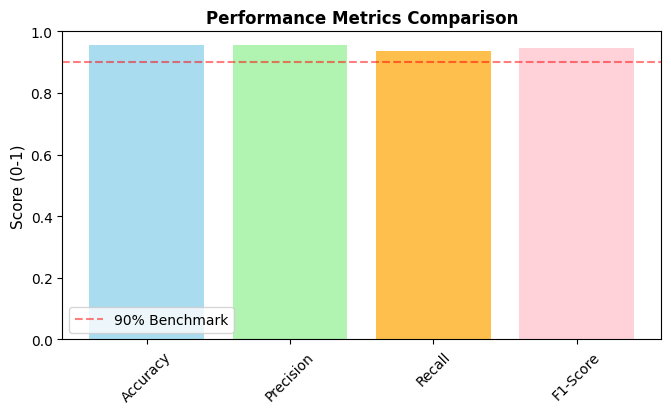

In [41]:
plt.figure(figsize=(17, 4))
# Subplot 1: Metrics comparison
plt.subplot(1, 2, 1)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [final_accuracy, final_precision, final_recall, final_f1]
colors = ['skyblue', 'lightgreen', 'orange', 'pink']
bars = plt.bar(metrics, values, color=colors, alpha=0.7)
plt.ylim(0, 1)
plt.title('Performance Metrics Comparison', fontweight='bold', fontsize=12)
plt.ylabel('Score (0-1)', fontsize=11)


# Add benchmark line
plt.axhline(y=0.9, color='red', linestyle='--', alpha=0.5, label='90% Benchmark')
plt.legend()
plt.xticks(rotation=45)

### Question 4: Analyze Confusion Matrix

Confusion Matrix (Mistake Analysis):
[[64  2]
 [ 3 45]]

How to read Confusion Matrix:

                 Skill Morph Predicted
              Benign   Malignant
Real Benign     64        2   ← 2 False Alarms (predicted malignant but was benign)
Real Malignant  3        45   ← 3 Missed Malignant (predicted benign but was malignant) ⚠️

✅ Correct Predictions: 109
❌ Wrong Predictions: 5

⚠️ DANGER: Missing malignant cancer (3 cases) is more dangerous than false alarms (2 cases)



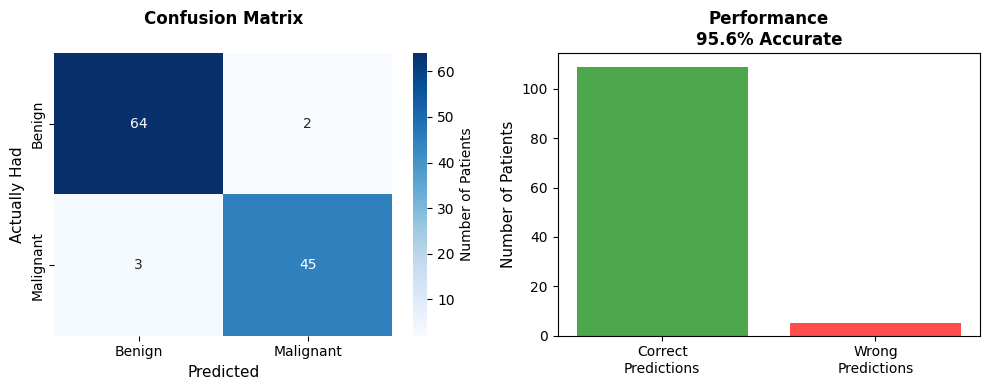

In [43]:
# Calculate confusion matrix
cm = confusion_matrix(y_test_new, fifth_predictions)
print("Confusion Matrix (Mistake Analysis):")
print(cm)

print("\nHow to read Confusion Matrix:")
print(f"""
                 Skill Morph Predicted
              Benign   Malignant
Real Benign     {cm[0,0]}        {cm[0,1]}   ← {cm[0,1]} False Alarms (predicted malignant but was benign)
Real Malignant  {cm[1,0]}        {cm[1,1]}   ← {cm[1,0]} Missed Malignant (predicted benign but was malignant) ⚠️

✅ Correct Predictions: {cm[0,0] + cm[1,1]}
❌ Wrong Predictions: {cm[0,1] + cm[1,0]}

⚠️ DANGER: Missing malignant cancer ({cm[1,0]} cases) is more dangerous than false alarms ({cm[0,1]} cases)
""")

# Create beautiful confusion matrix plot
plt.figure(figsize=(10, 4))

# Confusion Matrix Plot
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'],
            cbar_kws={'label': 'Number of Patients'})
plt.title('Confusion Matrix\n', fontweight='bold', fontsize=12)
plt.xlabel('Predicted', fontsize=11)
plt.ylabel('Actually Had', fontsize=11)

# Accuracy visualization
plt.subplot(1, 2, 2)
categories = ['Correct\nPredictions', 'Wrong\nPredictions']
values = [cm[0,0] + cm[1,1], cm[0,1] + cm[1,0]]
colors = ['green', 'red']
plt.bar(categories, values, color=colors, alpha=0.7)
plt.title(f'Performance\n{final_accuracy*100:.1f}% Accurate', fontweight='bold', fontsize=12)
plt.ylabel('Number of Patients', fontsize=11)

plt.tight_layout()
plt.show()